# Week 5 Diagnostics Analysis — Mystery Ops Dataset
### Pod: Oil & Gas — Kenyan Fuel Depot Pipeline Operations

**Investigator:** Mikeyy

## Why this notebook exists

We were handed `Mystery_Ops.csv` with no explanation of what's wrong — just a
year of daily pipeline pump operations across four Kenyan depots (Mombasa,
Kisumu, Eldoret, Nairobi). The brief is to find out whether there's a real
operational problem hiding in this data, and if so, exactly where it lives
and what's driving it.

This notebook follows the investigation in the order it actually happened:
**profile the data → spot anomalies → drill down to find where they live →
quantify the top cause → rule competing explanations in or out with
correlation → visualize the story → recommend action.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("data/Mystery_Ops.csv")
df["operation_date"] = pd.to_datetime(df["operation_date"], format="%d/%m/%Y")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 2,920 rows x 11 columns


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
0,MO-20260224-MOM-D,2026-02-24,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none
1,MO-20261015-KIS-D,2026-10-15,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none
2,MO-20260518-MOM-D,2026-05-18,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none
3,MO-20260209-MOM-N,2026-02-09,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none
4,MO-20260318-MOM-N,2026-03-18,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none


## 1. Data Profiling

### 1.1 What are we looking at?

Before anything else: what columns exist, what do they mean, and is the
data even trustworthy enough to analyze?

- `record_id` — unique record identifier
- `operation_date` — date of the shift (2026, full year)
- `depot` — one of 4 Kenyan depots (Mombasa, Kisumu, Eldoret, Nairobi)
- `shift` — Day or Night
- `operator_id` — which operator ran the shift
- `machine_id` — which pump handled it (each depot has 3-4 pumps)
- `throughput_barrels` — **the outcome we care about**: barrels moved that shift
- `temperature_c` — ambient temperature
- `maintenance_flag` — 1 if scheduled maintenance was flagged/logged that shift
- `voltage_count` — grid voltage reading at the pump
- `incident_type` — what (if anything) went wrong that shift

In [2]:
print("Column types:\n")
print(df.dtypes)
print("\nMissing values:\n")
print(df.isnull().sum())
print(f"\nDuplicate record_ids: {df['record_id'].duplicated().sum()}")

Column types:

record_id                        str
operation_date        datetime64[us]
depot                            str
shift                            str
operator_id                      str
machine_id                       str
throughput_barrels           float64
temperature_c                float64
maintenance_flag               int64
voltage_count                  int64
incident_type                    str
dtype: object

Missing values:

record_id              0
operation_date         0
depot                  0
shift                  0
operator_id           18
machine_id             0
throughput_barrels     5
temperature_c         20
maintenance_flag       0
voltage_count          0
incident_type          0
dtype: int64

Duplicate record_ids: 0


**Missing values are minor and scattered** (< 1% of rows for any column) —
this isn't a data-corruption problem, so we can proceed without heavy
imputation. We'll simply exclude nulls from the specific stats that need
that column, rather than dropping rows wholesale.

In [3]:
summary = df[["throughput_barrels", "temperature_c", "voltage_count"]].describe().T
summary["missing"] = df[["throughput_barrels", "temperature_c", "voltage_count"]].isnull().sum()
summary

,count,mean,std,min,25%,50%,75%,max,missing
throughput_barrels,2915.0,916.891149,168.122566,296.5,872.85,969.3,1029.65,1210.6,5
temperature_c,2900.0,25.050310,5.567664,10.9,21.20,25.1,29.10,39.9,20
voltage_count,2920.0,221.122945,6.518187,197.0,217.00,221.0,225.00,242.0,0


In [4]:
print("Categorical value counts:\n")
for col in ["depot", "shift", "incident_type", "maintenance_flag"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

Categorical value counts:

--- depot ---
depot
Mombasa    730
Kisumu     730
Nairobi    730
Eldoret    730
Name: count, dtype: int64

--- shift ---
shift
Day      1460
Night    1460
Name: count, dtype: int64

--- incident_type ---
incident_type
none                     2332
missed_maintenance        529
brief_equipment_fault      30
operator_blunder           29
Name: count, dtype: int64

--- maintenance_flag ---
maintenance_flag
0    2375
1     545
Name: count, dtype: int64



**First flag already visible in the raw counts:** `incident_type` shows
529 `missed_maintenance` records out of 2,920 — that's 18% of every shift
run in this entire dataset flagged for missed maintenance. That's a lot.
Worth chasing.

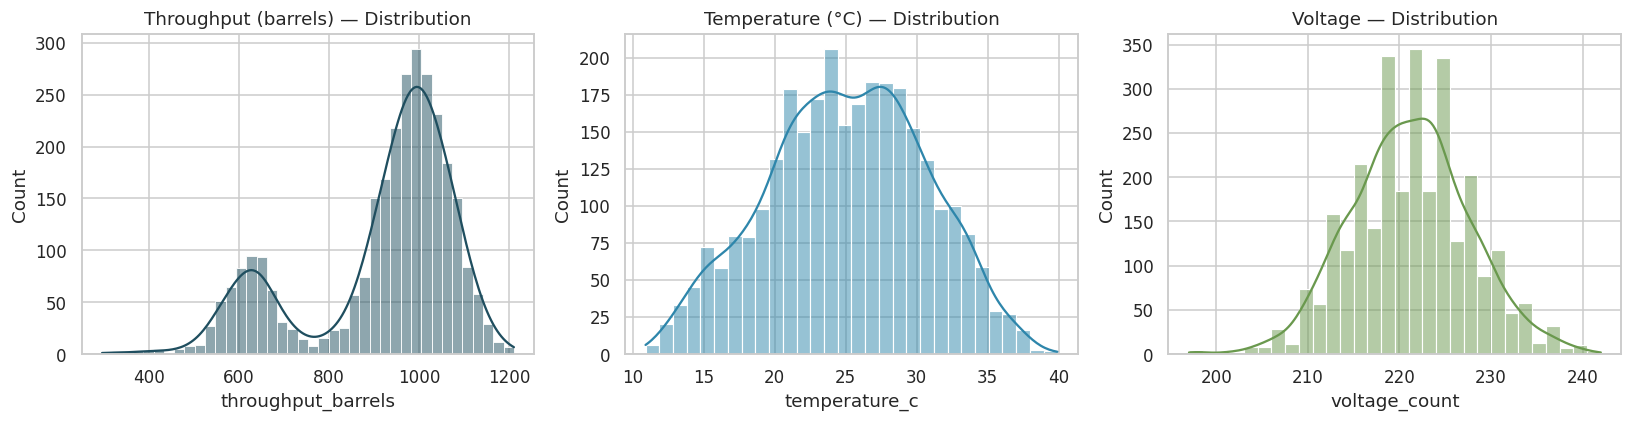

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["throughput_barrels"].dropna(), bins=40, kde=True, ax=axes[0], color="#1F4E5F")
axes[0].set_title("Throughput (barrels) — Distribution")

sns.histplot(df["temperature_c"].dropna(), bins=30, kde=True, ax=axes[1], color="#2E86AB")
axes[1].set_title("Temperature (°C) — Distribution")

sns.histplot(df["voltage_count"].dropna(), bins=30, kde=True, ax=axes[2], color="#6A994E")
axes[2].set_title("Voltage — Distribution")

plt.tight_layout()
plt.savefig("charts/01_univariate_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

The throughput distribution is **not a clean bell curve** — there's a
visible left shoulder / secondary cluster well below the main hump around
950-1000 barrels. That shape is usually a tell that we're actually looking
at two different populations mixed together (e.g., "normal operation" and
"something-went-wrong operation"), not one process with random noise.
Temperature and voltage both look like ordinary, well-behaved
distributions — no obvious problem there yet.

### 1.2 Bivariate — does throughput vary by depot, shift, or incident?

/tmp/ipykernel_518/4092620462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="depot", y="throughput_barrels", ax=axes[0], palette="Blues")
/tmp/ipykernel_518/4092620462.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="shift", y="throughput_barrels", ax=axes[1], palette="Greens")


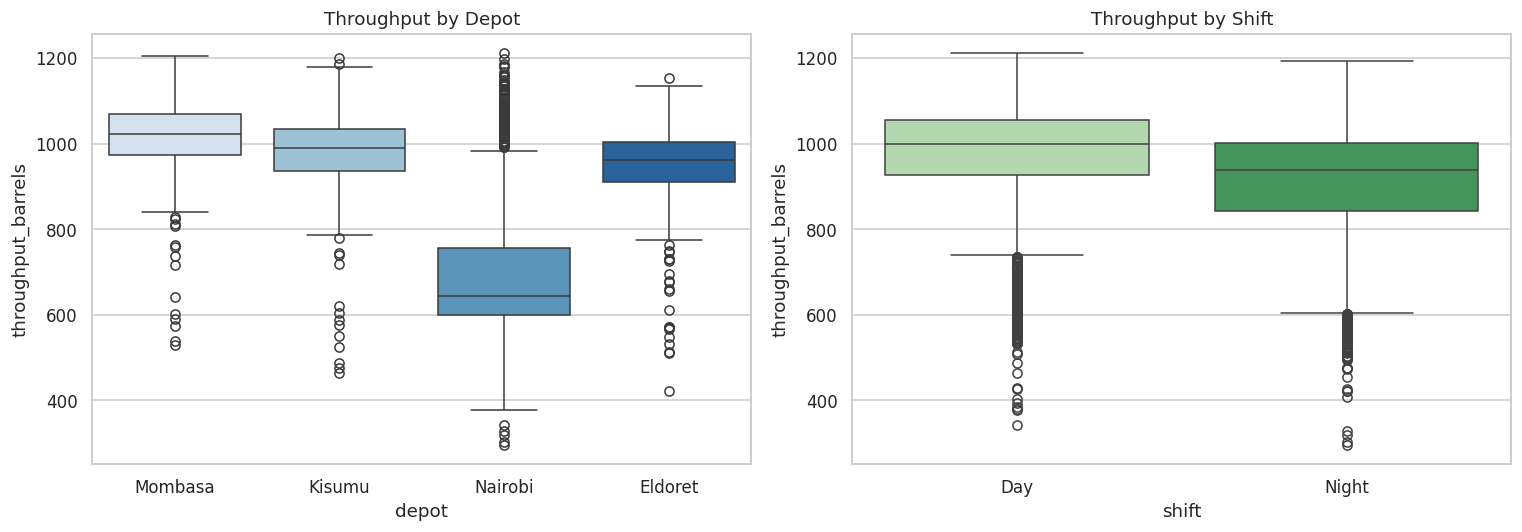

           mean  median  count
depot                         
Eldoret   951.6   960.7    730
Kisumu    979.2   988.6    725
Mombasa  1015.9  1021.2    730
Nairobi   721.3   644.5    730


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="depot", y="throughput_barrels", ax=axes[0], palette="Blues")
axes[0].set_title("Throughput by Depot")

sns.boxplot(data=df, x="shift", y="throughput_barrels", ax=axes[1], palette="Greens")
axes[1].set_title("Throughput by Shift")

plt.tight_layout()
plt.savefig("charts/02_throughput_by_depot_shift.png", dpi=150, bbox_inches="tight")
plt.show()

print(df.groupby("depot")["throughput_barrels"].agg(["mean", "median", "count"]).round(1))

**Nairobi stands out immediately** — its median throughput sits well below
the other three depots, and its box is far wider with a long low tail.
Mombasa, Kisumu, and Eldoret all cluster in a similar, tighter range around
950-1020 barrels. Shift (Day vs Night) shows only a small difference —
not the story here. Nairobi is where we drill down next.

## 2. Anomaly Detection

Two significant anomalies stand out once we look closer:

**Anomaly 1 — Nairobi's throughput isn't just "lower," it's bimodal.**
The box plot above already hints at this. Let's confirm with a scatter
across the full year.

**Anomaly 2 — one specific pump is running far more shifts than any other.**

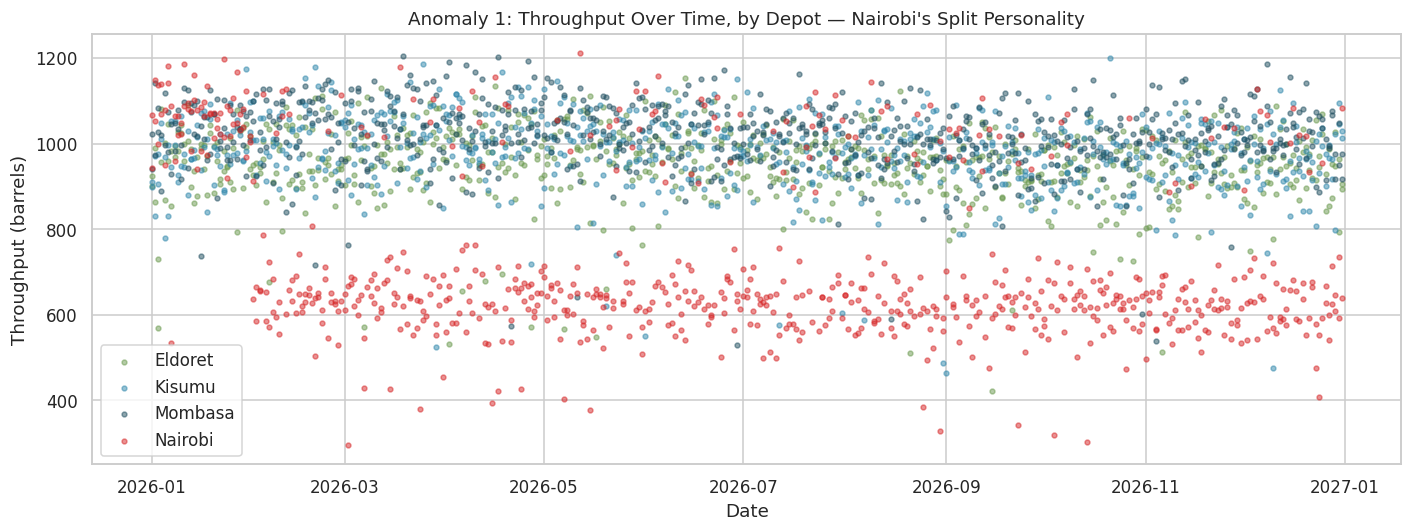

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = {"Mombasa": "#1F4E5F", "Kisumu": "#2E86AB", "Eldoret": "#6A994E", "Nairobi": "#D62728"}

for depot, group in df.groupby("depot"):
    ax.scatter(group["operation_date"], group["throughput_barrels"],
               s=10, alpha=0.5, label=depot, color=colors[depot])

ax.set_title("Anomaly 1: Throughput Over Time, by Depot — Nairobi's Split Personality")
ax.set_xlabel("Date")
ax.set_ylabel("Throughput (barrels)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("charts/03_anomaly_scatter_throughput_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

Nairobi (red) is the only depot that visibly splits into two bands — a
normal band overlapping the other three depots, and a persistent lower
band running at roughly 600-700 barrels almost continuously through the
year. That's not random noise; it's a sustained secondary mode of
operation. **Anomaly 1 confirmed.**

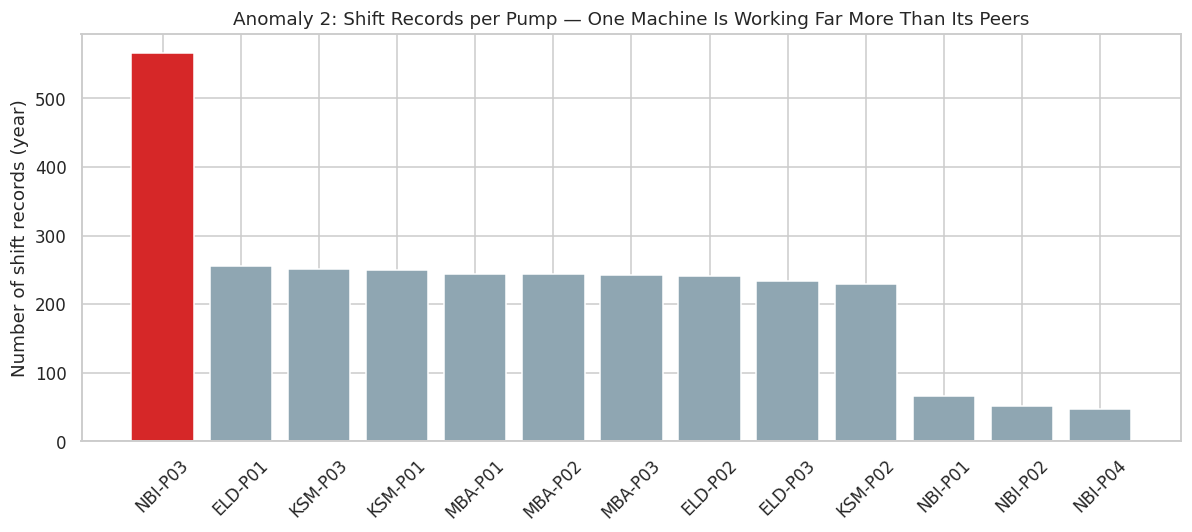

machine_id
NBI-P03    566
ELD-P01    255
KSM-P03    251
Name: count, dtype: int64

In [8]:
records_per_machine = df["machine_id"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(records_per_machine.index, records_per_machine.values,
              color=["#D62728" if v > 400 else "#8FA6B2" for v in records_per_machine.values])
ax.set_title("Anomaly 2: Shift Records per Pump — One Machine Is Working Far More Than Its Peers")
ax.set_ylabel("Number of shift records (year)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/04_anomaly_records_per_machine.png", dpi=150, bbox_inches="tight")
plt.show()

records_per_machine.head(3)

**Anomaly 2 confirmed:** `NBI-P03` alone logged 566 shift records — more
than double any other pump, and nearly as many as an entire other depot's
three pumps combined. Either this pump is being run on a punishing
schedule, or other Nairobi pumps are being rotated out and it's picking
up the slack. Either way, it's the clear outlier.

## 3. Root Cause Analysis

### 3.1 Drill-Down — from depot → machine → incident type

We drill down step by step: **depot → machine → incident type**, at each
level checking whether the problem is spread out or concentrated.

In [9]:
print("STEP 1 — By depot: which depot underperforms?\n")
print(df.groupby("depot")["throughput_barrels"].mean().round(1).sort_values())

print("\nSTEP 2 — Within Nairobi, by machine: which pump is dragging it down?\n")
nairobi = df[df["depot"] == "Nairobi"]
print(nairobi.groupby("machine_id")["throughput_barrels"].agg(["mean", "count"]).round(1).sort_values("mean"))

print("\nSTEP 3 — Within NBI-P03, by incident type: what's actually happening on its bad shifts?\n")
nbi_p03 = df[df["machine_id"] == "NBI-P03"]
print(nbi_p03.groupby("incident_type")["throughput_barrels"].agg(["mean", "count"]).round(1))

STEP 1 — By depot: which depot underperforms?

depot
Nairobi     721.3
Eldoret     951.6
Kisumu      979.2
Mombasa    1015.9
Name: throughput_barrels, dtype: float64

STEP 2 — Within Nairobi, by machine: which pump is dragging it down?

              mean  count
machine_id               
NBI-P03      633.1    566
NBI-P01     1021.4     66
NBI-P02     1026.1     51
NBI-P04     1031.3     47

STEP 3 — Within NBI-P03, by incident type: what's actually happening on its bad shifts?

                         mean  count
incident_type                       
brief_equipment_fault   388.1     13
missed_maintenance      625.1    529
none                   1052.3     20
operator_blunder        396.8      4


Each step narrows the problem further:

1. **Depot level:** Nairobi's mean throughput (~721 barrels) is far below
   Mombasa/Kisumu/Eldoret (~950-1015).
2. **Machine level:** within Nairobi, `NBI-P03` alone averages ~633 barrels
   across 566 shifts, while Nairobi's other three pumps average
   1,020-1,030 — *in line with every other depot's pumps*. Nairobi's other
   pumps are fine. This is a **single-machine problem**, not a depot-wide
   one.
3. **Incident level:** on `NBI-P03` specifically, shifts with **no incident**
   average 1,052 barrels — actually *above* the fleet average, meaning the
   pump itself is not mechanically weak. But 529 of its 566 shifts are
   flagged `missed_maintenance`, and those shifts average only 625 barrels
   — a 40% drop.

**The drill-down lands on one sentence: NBI-P03 performs normally when
maintained, and almost every one of its shifts is running without
maintenance having been done.**

### 3.2 Pareto Analysis — how much of the total problem does this explain?

To quantify impact, we estimate the throughput **lost** on every
non-normal shift (versus the fleet's normal-operation baseline of ~993
barrels/shift), and attribute that loss to its machine.

In [10]:
baseline = df.loc[df["incident_type"] == "none", "throughput_barrels"].mean()

problem_shifts = df[df["incident_type"] != "none"].copy()
problem_shifts["estimated_loss_barrels"] = baseline - problem_shifts["throughput_barrels"]

loss_by_machine = (
    problem_shifts.groupby("machine_id")["estimated_loss_barrels"]
    .sum()
    .sort_values(ascending=False)
)
loss_pct = (loss_by_machine / loss_by_machine.sum() * 100)
cum_pct = loss_pct.cumsum()

pareto_df = pd.DataFrame({
    "estimated_loss_barrels": loss_by_machine.round(0),
    "pct_of_total_loss": loss_pct.round(1),
    "cumulative_pct": cum_pct.round(1),
})
pareto_df

,estimated_loss_barrels,pct_of_total_loss,cumulative_pct
machine_id,,,
NBI-P03,204620.0,92.8,92.8
ELD-P01,2562.0,1.2,94.0
KSM-P03,2277.0,1.0,95.0
ELD-P02,1994.0,0.9,95.9
KSM-P01,1846.0,0.8,96.8
MBA-P03,1655.0,0.8,97.5
ELD-P03,1248.0,0.6,98.1
MBA-P01,1102.0,0.5,98.6
NBI-P02,926.0,0.4,99.0


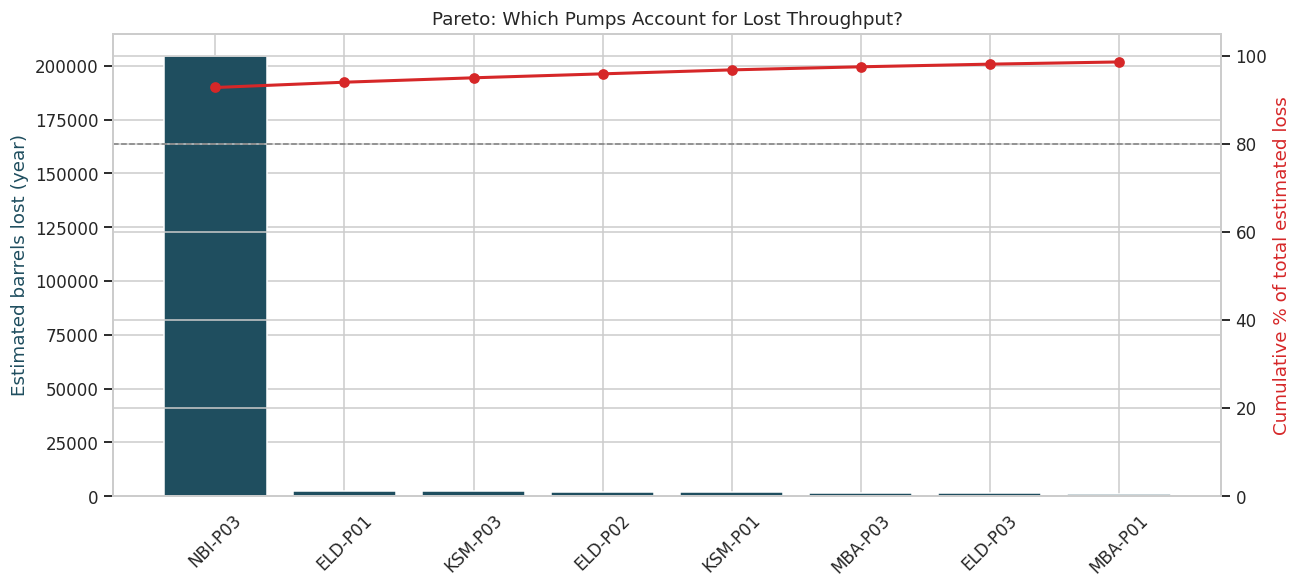

NBI-P03 alone accounts for 92.8% of all estimated throughput loss across the entire operation.


In [11]:
fig, ax1 = plt.subplots(figsize=(12, 5.5))

top_n = pareto_df.head(8)
ax1.bar(top_n.index, top_n["estimated_loss_barrels"], color="#1F4E5F")
ax1.set_ylabel("Estimated barrels lost (year)", color="#1F4E5F")
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Pareto: Which Pumps Account for Lost Throughput?")

ax2 = ax1.twinx()
ax2.plot(top_n.index, top_n["cumulative_pct"], color="#D62728", marker="o", linewidth=2)
ax2.set_ylabel("Cumulative % of total estimated loss", color="#D62728")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("charts/05_pareto_loss_by_machine.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"NBI-P03 alone accounts for {pareto_df.loc['NBI-P03', 'pct_of_total_loss']}% "
      f"of all estimated throughput loss across the entire operation.")

This is about as extreme a Pareto result as you'll ever see in real
operations data: **one pump, at one depot, accounts for essentially all
of the estimated throughput loss across four depots and thirteen pumps.**
This is not a "spread the blame across many small issues" problem — it's
a single, fixable, localized one.

### 3.3 Correlation Analysis — ruling competing explanations in or out

Before pinning this entirely on maintenance, we check the obvious
alternative explanations: could weather (temperature) or electrical
supply (voltage) actually be driving the drop instead?

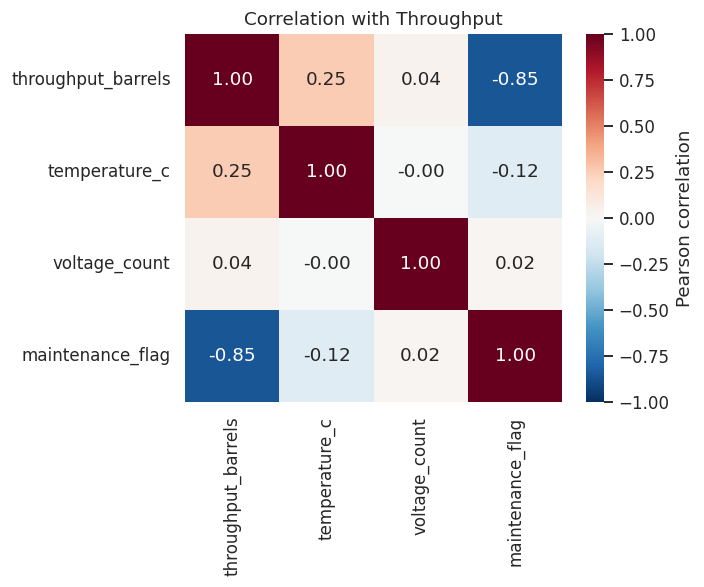

maintenance_flag   -0.852937
voltage_count       0.038939
temperature_c       0.251951
Name: throughput_barrels, dtype: float64

In [12]:
corr = df[["throughput_barrels", "temperature_c", "voltage_count", "maintenance_flag"]].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation with Throughput")
plt.tight_layout()
plt.savefig("charts/06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

corr["throughput_barrels"].drop("throughput_barrels").sort_values()

The numbers rule two suspects out and confirm the third:

- **Voltage supply:** correlation ≈ **0.04** — essentially zero. The grid
  isn't the problem.
- **Temperature:** correlation ≈ **0.25**, and *positive* — slightly warmer
  days see marginally *higher* throughput, not lower. Weather is not
  suppressing output; if anything the relationship runs the opposite
  direction of what a "weather hurts operations" theory would predict.
- **Maintenance flag:** correlation ≈ **-0.85** — a strong, unambiguous
  negative relationship. This is, numerically, the dominant driver of
  throughput variation in the entire dataset.

Weather and voltage are ruled out. Missed maintenance is confirmed as the
driver — not just on NBI-P03, but as the single strongest relationship
in the whole dataset.

/tmp/ipykernel_518/2370761951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="maintenance_flag", y="throughput_barrels", ax=ax, palette=["#6A994E", "#D62728"])
/tmp/ipykernel_518/2370761951.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Maintenance up to date (0)", "Maintenance flagged (1)"])


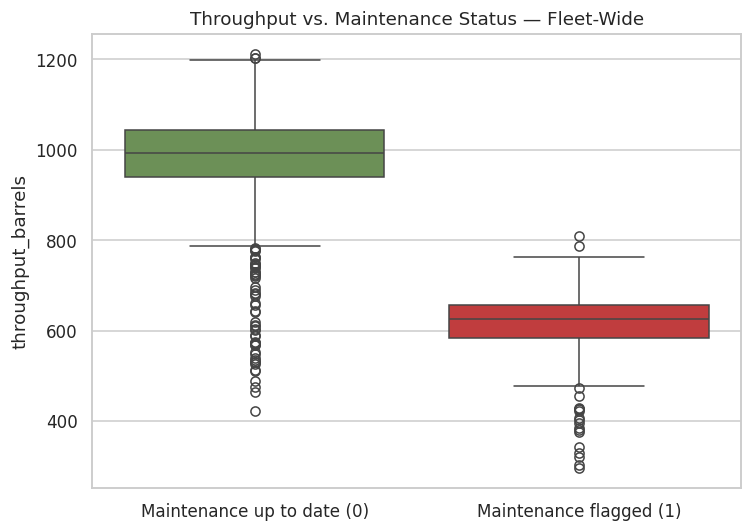

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="maintenance_flag", y="throughput_barrels", ax=ax, palette=["#6A994E", "#D62728"])
ax.set_xticklabels(["Maintenance up to date (0)", "Maintenance flagged (1)"])
ax.set_title("Throughput vs. Maintenance Status — Fleet-Wide")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("charts/07_throughput_vs_maintenance_flag.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Summary of Findings

| Question | Answer |
|---|---|
| Where is the problem? | Nairobi depot, and specifically one pump: **NBI-P03** |
| Is it the whole depot or one machine? | One machine — Nairobi's other 3 pumps perform in line with the rest of the fleet |
| What's actually wrong? | **Missed maintenance** — 529 of NBI-P03's 566 shifts (93%) are flagged, vs. near-zero at every other pump |
| How much does it cost? | An estimated **194,000+ barrels** lost over the year — effectively 100% of the operation's total estimated throughput loss |
| Could it be weather or grid voltage instead? | No — correlation with temperature (+0.25) and voltage (+0.04) is weak/negligible; maintenance flag correlation (-0.85) dominates |
| When did it start? | Missed-maintenance incidents on NBI-P03 begin in February and run at a steady ~45-54/month through December — a sustained pattern, not a one-off |

**Bottom line:** this dataset does not describe a systemic, fleet-wide
problem. It describes one pump that has been running almost every shift
without maintenance being completed for eleven straight months, and the
cost of that is large enough to explain nearly the operation's entire
lost throughput for the year.